**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Production economy and CO2 taxation](#toc1_)    
- 2. [Problem 2: Career choice model](#toc2_)    
- 3. [Problem 3: Barycentric interpolation](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [710]:
# Write your code here
import numpy as np
from types import SimpleNamespace
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, minimize

## 1. <a id='toc1_'></a>[Problem 1: Production economy and CO2 taxation](#toc0_)

Consider a production economy with two firms indexed by $j \in \{1,2\}$. Each produce its own good. They solve

$$
\begin{align*}
\max_{y_{j}}\pi_{j}&=p_{j}y_{j}-w_{j}\ell_{j}\\\text{s.t.}\;&y_{j}=A\ell_{j}^{\gamma}.
\end{align*}
$$

Optimal firm behavior is

$$
\begin{align*}
\ell_{j}^{\star}(w,p_{j})&=\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}} \\
y_{j}^{\star}(w,p_{j})&=A\left(\ell_{j}^{\star}(w,p_{j})\right)^{\gamma}
\end{align*}
$$

The implied profits are

$$
\pi_{j}^*(w,p_{j})=\frac{1-\gamma}{\gamma}w\cdot\left(\frac{p_{j}A\gamma}{w}\right)^{\frac{1}{1-\gamma}}
$$

A single consumer supplies labor, and consumes the goods the firms produce. She also recieves the implied profits of the firm.<br>
She solves:

$$
\begin{align*}
U(p_1,p_2,w,\tau,T) = \max_{c_{1},c_{2},\ell} & \log(c_{1}^{\alpha}c_{2}^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} \\
\text{s.t.}\,\,\,&p_{1}c_{1}+(p_{2}+\tau)c_{2}=w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})
\end{align*}
$$

where $\tau$ is a tax and $T$ is lump-sum transfer. <br>
For a given $\ell$, it can be shown that optimal behavior is

$$
\begin{align*}
c_{1}(\ell)&=\alpha\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{1}} \\
c_{2}(\ell)&=(1-\alpha)\frac{w\ell+T+\pi_{1}^*(w,p_{1})+\pi_{2}^*(w,p_{2})}{p_{2}+\tau} \\
\end{align*}
$$
Such that optimal behavior is:
$$
\ell^* = \underset{\ell}{\arg\max} \log(\left(c_{1}(\ell)\right)^{\alpha}\cdot \left(c_{2}(\ell)\right)^{1-\alpha})-\nu\frac{\ell^{1+\epsilon}}{1+\epsilon} 
$$
With optimal consumption:
$$
\begin{align*}
c_1^*=c_{1}(\ell^*) \\
c_2^*=c_{2}(\ell^*)\\
\end{align*}
$$


The government chooses $\tau$ and balances its budget so $T=\tau c_2^*$. We initially set $\tau,T=0$.

Market clearing requires:

1. Labor market: $\ell^* = \ell_1^* + \ell_2^*$
1. Good market 1: $c_1^* = y_1^*$
1. Good market 2: $c_2^* = y_2^*$


**Question 1:** Check market clearing conditions for $p_1$ in `linspace(0.1,2.0,10)` and $p_2$ in `linspace(0.1,2.0,10)`. We choose $w=1$ as numeraire.

In [711]:
par = SimpleNamespace()

# firms
par.A = 1.0
par.gamma = 0.5

# households
par.alpha = 0.3
par.nu = 1.0
par.epsilon = 2.0

# government
par.tau = 0.0
par.T = 0.0

# Question 3
par.kappa = 0.1

In [712]:

# Define the parameters
A1 = 1
A2 = 1
gamma = 0.5
alpha = 0.5
eta = 1.5
sigma = 2
w = 1
tau = 0
T = 0

# Define the functions based on the given equations
def ell_j(w, pj, Aj=A1, gamma=gamma):
    return ((pj * Aj * gamma) / w)**(1 / (1 - gamma))

def y_j(w, pj, Aj=A1, gamma=gamma):
    return Aj * (ell_j(w, pj, Aj, gamma))**gamma

def pi_j_star(w, pj, Aj=A1, gamma=gamma):
    return (1 - gamma) / gamma * w * ell_j(w, pj, Aj, gamma)

def c1(l, w=w, T=T, p1=1, p2=1, alpha=alpha):
    return alpha * (w * l + T + pi_j_star(w, p1) + pi_j_star(w, p2, A2)) / p1

def c2(l, w=w, T=T, p1=1, p2=1, alpha=alpha):
    return (1 - alpha) * (w * l + T + pi_j_star(w, p1) + pi_j_star(w, p2, A2)) / p2

def labor_supply(l, eta=eta):
    return l - (c1(l) * c2(l))**(1/eta)

# Define the ranges for p1 and p2
p1_values = np.linspace(0.1, 2.0, 10)
p2_values = np.linspace(0.1, 2.0, 10)

# Check market clearing conditions
results = []

for p1 in p1_values:
    for p2 in p2_values:
        l = labor_supply(ell_j(w, p1) + ell_j(w, p2, A2))
        y1 = y_j(w, p1)
        y2 = y_j(w, p2, A2)
        c1_val = c1(l, p1=p1, p2=p2)
        c2_val = c2(l, p1=p1, p2=p2)
        
        market_clearing = {
            'p1': p1,
            'p2': p2,
            'labor_supply_clears': np.isclose(l, ell_j(w, p1) + ell_j(w, p2, A2)),
            'good_1_clears': np.isclose(c1_val, y1),
            'good_2_clears': np.isclose(c2_val, y2)
        }
        
        results.append(market_clearing)

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the results
print("Market Clearing Results:")
print(results_df.to_string(index=False))

Market Clearing Results:
      p1       p2  labor_supply_clears  good_1_clears  good_2_clears
0.100000 0.100000                False          False          False
0.100000 0.311111                False          False          False
0.100000 0.522222                False          False          False
0.100000 0.733333                False          False          False
0.100000 0.944444                False          False          False
0.100000 1.155556                False          False          False
0.100000 1.366667                False          False          False
0.100000 1.577778                False          False          False
0.100000 1.788889                False          False          False
0.100000 2.000000                False          False          False
0.311111 0.100000                False          False          False
0.311111 0.311111                False          False          False
0.311111 0.522222                False          False          False
0.311111 

**Question 2:** Find the equilibrium prices $p_1$ and $p_2$.<br>
*Hint: you can use Walras' law to only check 2 of the market clearings*

In [713]:
# Define the market clearing conditions
def market_clearing_conditions(prices):
    p1, p2 = prices
    l = ell_j(w, p1) + ell_j(w, p2, A2)
    y1 = y_j(w, p1)
    y2 = y_j(w, p2, A2)
    c1_val = c1(l, p1=p1, p2=p2)
    c2_val = c2(l, p1=p1, p2=p2)
    
    # Check market clearing for goods 1 and 2
    good_1_clears = c1_val - y1
    good_2_clears = c2_val - y2
    
    return [good_1_clears, good_2_clears]

# Initial guess for p1 and p2
initial_guess = [1, 1]

# Find the equilibrium prices
equilibrium_prices = fsolve(market_clearing_conditions, initial_guess)

p1_eq, p2_eq = equilibrium_prices

print(f"Equilibrium prices: p1 = {p1_eq}, p2 = {p2_eq}")

# Assume the government cares about the social welfare function
def social_welfare(l):
    c1_val = c1(l, p1=p1_eq, p2=p2_eq)
    c2_val = c2(l, p1=p1_eq, p2=p2_eq)
    welfare = (c1_val**(1-sigma) - 1) / (1-sigma) + (c2_val**(1-sigma) - 1) / (1-sigma) - (l**(1+eta) / (1+eta))
    return -welfare  # Minimize the negative of welfare for maximization

# Calculate the optimal labor supply that maximizes social welfare
result = minimize(social_welfare, ell_j(w, p1_eq) + ell_j(w, p2_eq, A2), method='BFGS')
optimal_l = result.x[0]

print(f"Optimal labor supply that maximizes social welfare: {optimal_l}")

Equilibrium prices: p1 = 1.0, p2 = 1.0
Optimal labor supply that maximizes social welfare: 1.2214095715169222


Assume the government care about the social welfare function:

$$
SWF = U - \kappa y_2^*
$$

Here $\kappa$ measures the social cost of carbon emitted by the production of $y_2$ in equilibrium.

**Question 3:** What values of $\tau$ and (implied) $T$ should the government choose to maximize $SWF$?

In [726]:
kappa = 0.1
def social_welfare(params, p1=p1_eq, p2=p2_eq):
    l, tau = params
    T = tau * c2(l, p1=p1, p2=p2)
    c1_val = c1(l, p1=p1, p2=p2, T=T)
    c2_val = c2(l, p1=p1, p2=p2, T=T)
    y2_eq = y_j(w, p2, A2)
    welfare = (c1_val**(1-sigma) - 1) / (1-sigma) + (c2_val**(1-sigma) - 1) / (1-sigma) - (l**(1+eta) / (1+eta)) - kappa * y2_eq
    return -welfare  # Minimize the negative of welfare for maximization

# Initial guess and bounds for the optimization
initial_guess = [ell_j(w, p1_eq) + ell_j(w, p2_eq, A2), 0.1]
bounds = [(0.1, 10), (0.01, 1)]  # Reasonable bounds for labor supply and tau

# Perform the optimization
result = minimize(social_welfare, initial_guess, bounds=bounds, method='L-BFGS-B')
optimal_l, optimal_tau = result.x

print(f"Optimal labor supply that maximizes social welfare: {optimal_l}")
print(f"Optimal tax rate τ that maximizes social welfare: {optimal_tau}")

# Calculate the implied T
optimal_T = optimal_tau * c2(optimal_l, p1=p1_eq, p2=p2_eq)

print(f"Optimal transfer T that maximizes social welfare: {optimal_T}")

Optimal labor supply that maximizes social welfare: 1.061504063965598
Optimal tax rate τ that maximizes social welfare: 1.0
Optimal transfer T that maximizes social welfare: 0.780752031982799


## 2. <a id='toc2_'></a>[Problem 2: Career choice model](#toc0_)

Consider a graduate $i$ making a choice between entering $J$ different career tracks. <br>
Entering career $j$ yields utility $u^k_{ij}$. This value is unknown to the graduate ex ante, but will ex post be: <br>
$$
    u_{i,j}^k = v_{j} + \epsilon_{i,j}^k
$$

They know that $\epsilon^k_{i,j}\sim \mathcal{N}(0,\sigma^2)$, but they do not observe $\epsilon^k_{i,j}$ before making their career choice. <br>

Consider the concrete case of $J=3$ with:
$$
\begin{align*}
    v_{1} &= 1 \\
    v_{2} &= 2 \\
    v_{3} &= 3
\end{align*}
$$

If the graduates know the values of $v_j$ and the distribution of $\epsilon_{i,j}^k$, they can calculate the expected utility of each career track using simulation: <br>
$$
    \mathbb{E}\left[ u^k_{i,j}\vert v_j \right] \approx v_j + \frac{1}{K}\sum_{k=1}^K \epsilon_{i,j}^k
$$

In [715]:
par = SimpleNamespace()
par.J = 3
par.N = 10
par.K = 10000

par.F = np.arange(1,par.N+1)
par.sigma = 2

par.v = np.array([1,2,3])
par.c = 1

**Question 1:** Simulate and calculate expected utility and the average realised utility for $K=10000$ draws, for each career choice $j$.


In [716]:
# Define parameters
J = 3  # Number of career choices
N = 10  # Number of graduates (not used in this particular simulation)
K = 10000  # Number of simulations
sigma = 2  # Standard deviation of the noise term

# Career values
v = np.array([1, 2, 3])

# Simulate and calculate expected utility for each career choice
expected_utilities = np.zeros(J)

for j in range(J):
    # Simulate K draws of epsilon for career choice j
    epsilon_kj = np.random.normal(0, sigma, K)
    
    # Calculate expected utility
    expected_utility = v[j] + (1 / K) * np.sum(epsilon_kj)
    expected_utilities[j] = expected_utility

# Display results
for j in range(J):
    print(f"Expected utility for career choice {j+1}: {expected_utilities[j]}")

# Calculate average realised utility for each career choice
average_realised_utilities = np.zeros(J)

for j in range(J):
    # Simulate K draws of epsilon for career choice j
    epsilon_kj = np.random.normal(0, sigma, K)
    
    # Calculate realised utilities for all draws
    realised_utilities = v[j] + epsilon_kj
    
    # Calculate average realized utility
    average_realised_utility = np.mean(realised_utilities)
    average_realised_utilities[j] = average_realised_utility

average_realised_utilities
for j in range(J):
    print(f"Average realised utility {j+1}: {average_realised_utilities[j]}")



Expected utility for career choice 1: 0.9860592530514557
Expected utility for career choice 2: 1.9883946977049922
Expected utility for career choice 3: 3.0106665354656457
Average realised utility 1: 1.0062831099673892
Average realised utility 2: 2.012903174373877
Average realised utility 3: 3.013882492871504


Now consider a new scenario: Imagine that the graduate does not know $v_j$. The *only* prior information they have on the value of each job, comes from their $F_{i}$ friends that work in each career $j$. After talking with them, they know the average utility of their friends (which includes their friends' noise term), giving them the prior expecation: <br>
$$
\tilde{u}^k_{i,j}\left( F_{i}\right) = \frac{1}{F_{i}}\sum_{f=1}^{F_{i}} \left(v_{j} + \epsilon^k_{f,j}\right), \; \epsilon^k_{f,j}\sim \mathcal{N}(0,\sigma^2)
$$
For ease of notation consider that each graduate have $F_{i}=i$ friends in each career. <br>

For $K$ times do the following: <br>
1. For each person $i$ draw $J\cdot F_i$ values of $\epsilon_{f,j}^{k}$, and calculate the prior expected utility of each career track, $\tilde{u}^k_{i,j}\left( F_{i}\right)$. <br>
Also draw their own $J$ noise terms, $\epsilon_{i,j}^k$
1. Each person $i$ chooses the career track with the highest expected utility: $$j_i^{k*}= \arg\max_{j\in{1,2\dots,J}}\left\{ \tilde{u}^k_{i,j}\left( F_{i}\right)\right\} $$
1. Store the chosen careers: $j_i^{k*}$, the prior expectation of the value of their chosen career: $\tilde{u}^k_{i,j=j_i^{k*}}\left( F_{i}\right)$, and the realized value of their chosen career track: $u^k_{i,j=j_i^{k*}}=v_{j=j_i^{k*}}+\epsilon_{i,j=j_i^{k*}}^k$.

Chosen values will be: <br>
$i\in\left\{1,2\dots,N\right\}, N=10$ <br>
$F_i = i$<br>
So there are 10 graduates. The first has 1 friend in each career, the second has 2 friends, ... the tenth has 10 friends.

**Question 2:** Simulate and visualize: For each type of graduate, $i$, the share of graduates choosing each career, the average subjective expected utility of the graduates, and the average ex post realized utility given their choice. <br>
That is, calculate and visualize: <br>
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \mathbb{I}\left\{ j=j_i^{k*} \right\}  \;\forall j\in\left\{1,2,\dots,J\right\}
\end{align*}
$$
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} \tilde{u}^k_{ij=j_i^{k*}}\left( F_{i}\right)
\end{align*}
$$
And 
$$
\begin{align*}
    \frac{1}{K} \sum_{k=1}^{K} u^k_{ij=j_i^{k*}} 
\end{align*}
$$
For each graduate $i$.

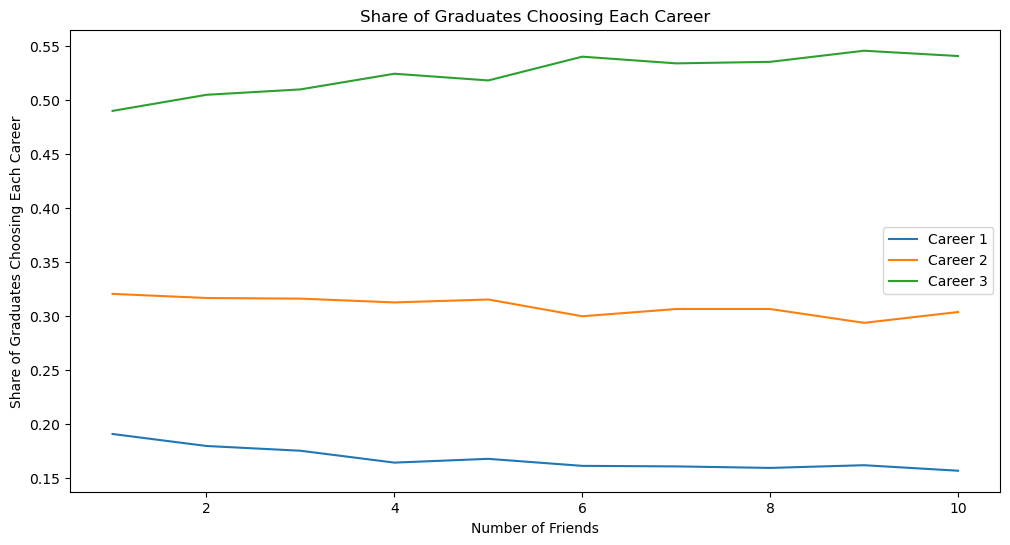

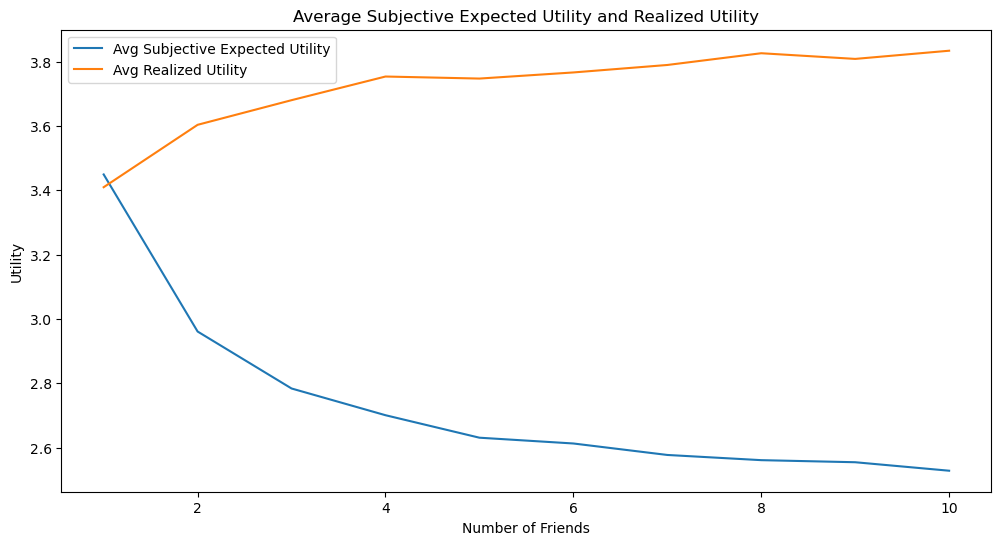

In [717]:
# Define parameters
J = 3  # Number of career choices
N = 10  # Number of graduates
K = 10000  # Number of simulations
sigma = 2  # Standard deviation of the noise term

# Career values
v = np.array([1, 2, 3])

# Number of friends in each career for each graduate
F = np.arange(1, N+1)

# Initialize arrays to store results
chosen_careers = np.zeros((N, K), dtype=int)
prior_expectation = np.zeros((N, K))
realized_values = np.zeros((N, K))

# Simulation
for k in range(K):
    for i in range(N):
        # Simulate friends' utilities for each career
        friends_utilities = np.zeros(J)
        for j in range(J):
            epsilon_friends = np.random.normal(0, sigma, F[i])
            friends_utilities[j] = np.mean(v[j] + epsilon_friends)
        
        # Calculate own noise term
        epsilon_i = np.random.normal(0, sigma, J)
        
        # Calculate expected utility
        expected_utility = friends_utilities + epsilon_i
        
        # Choose the career with the highest expected utility
        chosen_career = np.argmax(expected_utility)
        chosen_careers[i, k] = chosen_career
        prior_expectation[i, k] = friends_utilities[chosen_career]
        realized_values[i, k] = v[chosen_career] + epsilon_i[chosen_career]

# Calculate shares, average subjective expected utility, and average realized utility
shares = np.zeros((N, J))
avg_subjective_expected_utility = np.zeros(N)
avg_realized_utility = np.zeros(N)

for i in range(N):
    for j in range(J):
        shares[i, j] = np.mean(chosen_careers[i, :] == j)
    avg_subjective_expected_utility[i] = np.mean(prior_expectation[i, :])
    avg_realized_utility[i] = np.mean(realized_values[i, :])

# Visualization
plt.figure(figsize=(12, 6))
for j in range(J):
    plt.plot(F, shares[:, j], label=f'Career {j+1}')
plt.xlabel('Number of Friends')
plt.ylabel('Share of Graduates Choosing Each Career')
plt.legend()
plt.title('Share of Graduates Choosing Each Career')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(F, avg_subjective_expected_utility, label='Avg Subjective Expected Utility')
plt.plot(F, avg_realized_utility, label='Avg Realized Utility')
plt.xlabel('Number of Friends')
plt.ylabel('Utility')
plt.legend()
plt.title('Average Subjective Expected Utility and Realized Utility')
plt.show()

After a year of working in their career, the graduates learn $u^k_{ij}$ for their chosen job $j_i^{k*}$ perfectly. <br>
The can switch to one of the two remaining careers, for which they have the same prior as before, but it will now include a switching cost of $c$ which is known.
Their new priors can be written as: 
$$
\tilde{u}^{k,2}_{ij}\left( F_{i}\right) = \begin{cases}
            \tilde{u}^k_{ij}\left( F_{i}\right)-c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

We will set $c=1$.

Their realized utility will be: <br>
$$
u^{k,2}_{ij}= \begin{cases}
            u_{ij}^k -c & \text{if } j \neq j_i^{k*} \\
            u_{ij=j_i^{k*}} & \text{if } j = j_i^{k*}
        \end{cases}
$$

**Question 3:** Following the same approach as in question 2, find the new optimal career choice for each $i$, $k$. Then for each $i$, calculate the average subjective expected utility from their new optimal career choice, and the ex post realized utility of that career. Also, for each $i$, calculate the share of graduates that chooses to switch careers, conditional on which career they chose in the first year. <br>

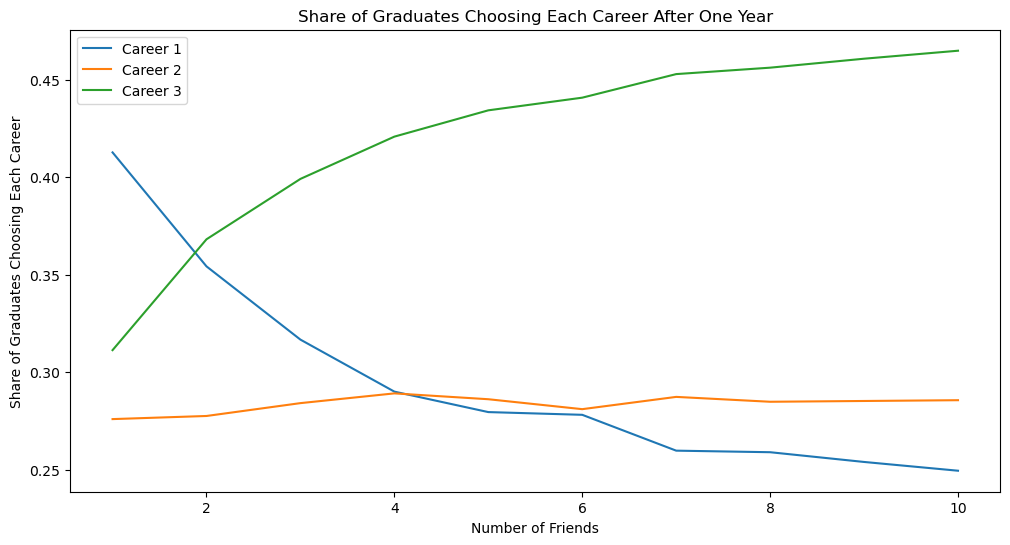

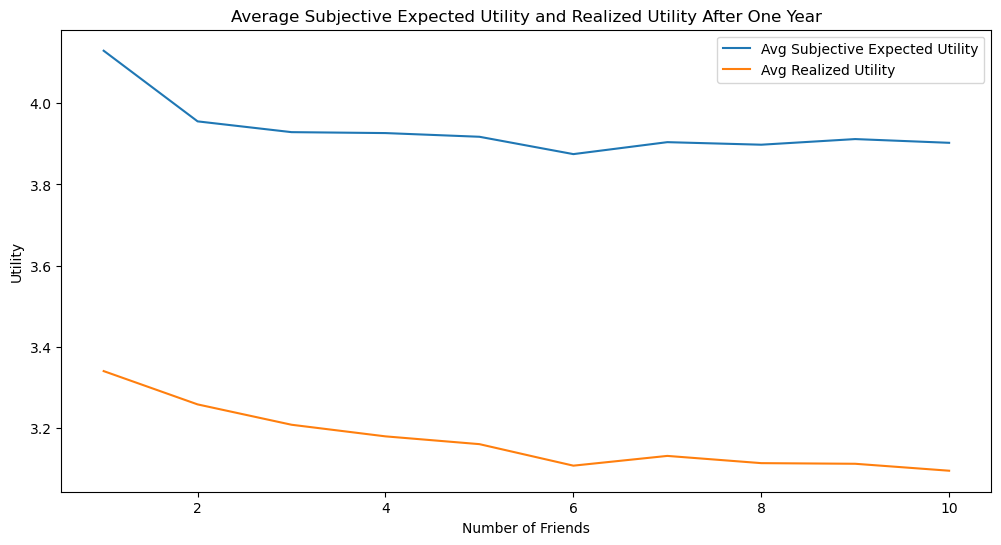

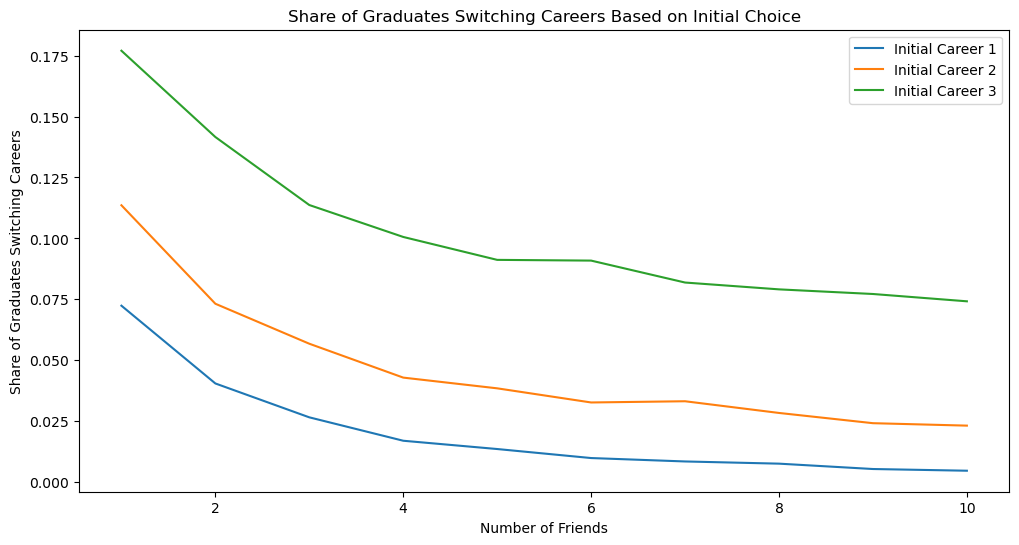

In [718]:
# Define parameters
J = 3  # Number of career choices
N = 10  # Number of graduates
K = 10000  # Number of simulations
sigma = 2  # Standard deviation of the noise term
c = 1  # Switching cost

# Career values
v = np.array([1, 2, 3])

# Number of friends in each career for each graduate
F = np.arange(1, N+1)

# Initialize arrays to store results
chosen_careers = np.zeros((N, K), dtype=int)
prior_expectation = np.zeros((N, K))
realized_values = np.zeros((N, K))
new_chosen_careers = np.zeros((N, K), dtype=int)
new_prior_expectation = np.zeros((N, K))
new_realized_values = np.zeros((N, K))

# Initial Simulation
for k in range(K):
    for i in range(N):
        # Simulate friends' utilities for each career
        friends_utilities = np.zeros(J)
        for j in range(J):
            epsilon_friends = np.random.normal(0, sigma, F[i])
            friends_utilities[j] = np.mean(v[j] + epsilon_friends)
        
        # Calculate own noise term
        epsilon_i = np.random.normal(0, sigma, J)
        
        # Calculate expected utility
        expected_utility = friends_utilities + epsilon_i
        
        # Choose the career with the highest expected utility
        chosen_career = np.argmax(expected_utility)
        chosen_careers[i, k] = chosen_career
        prior_expectation[i, k] = friends_utilities[chosen_career]
        realized_values[i, k] = v[chosen_career] + epsilon_i[chosen_career]

# New Optimal Career Choice After Learning Realized Utility
switch_counts = np.zeros((N, J))
for k in range(K):
    for i in range(N):
        # Learning realized utility of the chosen career
        learned_utility = realized_values[i, k]
        initial_chosen_career = chosen_careers[i, k]
        
        # Calculate new subjective expected utilities with switching cost
        new_expected_utilities = np.zeros(J)
        for j in range(J):
            if j == initial_chosen_career:
                new_expected_utilities[j] = learned_utility
            else:
                new_expected_utilities[j] = prior_expectation[i, k] - c
        
        # Choose the new optimal career
        new_chosen_career = np.argmax(new_expected_utilities)
        new_chosen_careers[i, k] = new_chosen_career
        new_prior_expectation[i, k] = new_expected_utilities[new_chosen_career]
        new_realized_values[i, k] = v[new_chosen_career] + epsilon_i[new_chosen_career] if new_chosen_career != initial_chosen_career else learned_utility - c
        
        # Count switches
        if new_chosen_career != initial_chosen_career:
            switch_counts[i, initial_chosen_career] += 1

# Calculate shares, average subjective expected utility, and average realized utility for the new choices
shares_new = np.zeros((N, J))
avg_subjective_expected_utility_new = np.zeros(N)
avg_realized_utility_new = np.zeros(N)
switch_shares = np.zeros((N, J))

for i in range(N):
    for j in range(J):
        shares_new[i, j] = np.mean(new_chosen_careers[i, :] == j)
        switch_shares[i, j] = switch_counts[i, j] / K
    avg_subjective_expected_utility_new[i] = np.mean(new_prior_expectation[i, :])
    avg_realized_utility_new[i] = np.mean(new_realized_values[i, :])

# Visualization
plt.figure(figsize=(12, 6))
for j in range(J):
    plt.plot(F, shares_new[:, j], label=f'Career {j+1}')
plt.xlabel('Number of Friends')
plt.ylabel('Share of Graduates Choosing Each Career')
plt.legend()
plt.title('Share of Graduates Choosing Each Career After One Year')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(F, avg_subjective_expected_utility_new, label='Avg Subjective Expected Utility')
plt.plot(F, avg_realized_utility_new, label='Avg Realized Utility')
plt.xlabel('Number of Friends')
plt.ylabel('Utility')
plt.legend()
plt.title('Average Subjective Expected Utility and Realized Utility After One Year')
plt.show()

# Conditional switch shares visualization
plt.figure(figsize=(12, 6))
for j in range(J):
    plt.plot(F, switch_shares[:, j], label=f'Initial Career {j+1}')
plt.xlabel('Number of Friends')
plt.ylabel('Share of Graduates Switching Careers')
plt.legend()
plt.title('Share of Graduates Switching Careers Based on Initial Choice')
plt.show()

## 3. <a id='toc3_'></a>[Problem 3: Barycentric interpolation](#toc0_)

**Problem:** We have a set of random points in the unit square,

$$
\mathcal{X} = \{(x_1,x_2)\,|\,x_1\sim\mathcal{U}(0,1),x_2\sim\mathcal{U}(0,1)\}.
$$

For these points, we know the value of some function $f(x_1,x_2)$,

$$
\mathcal{F} = \{f(x_1,x_2) \,|\, (x_1,x_2) \in \mathcal{X}\}.
$$

Now we want to approximate the value $f(y_1,y_2)$ for some  $y=(y_1,y_2)$, where $y_1\sim\mathcal{U}(0,1)$ and $y_2\sim\mathcal{U}(0,1)$.

**Building block I**

For an arbitrary triangle $ABC$ and a point $y$, define the so-called barycentric coordinates as:

$$
\begin{align*}
  r^{ABC}_1 &= \frac{(B_2-C_2)(y_1-C_1) + (C_1-B_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_2 &= \frac{(C_2-A_2)(y_1-C_1) + (A_1-C_1)(y_2-C_2)}{(B_2-C_2)(A_1-C_1) + (C_1-B_1)(A_2-C_2)} \\
  r^{ABC}_3 &= 1 - r_1 - r_2.
\end{align*}
$$

If $r^{ABC}_1 \in [0,1]$, $r^{ABC}_2 \in [0,1]$, and $r^{ABC}_3 \in [0,1]$, then the point is inside the triangle.

We always have $y = r^{ABC}_1 A + r^{ABC}_2 B + r^{ABC}_3 C$.

**Building block II**

Define the following points:

$$
\begin{align*}
A&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}>y_{2}\\
B&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}>y_{1}\text{ and }x_{2}<y_{2}\\
C&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}<y_{2}\\
D&=\arg\min_{(x_{1},x_{2})\in\mathcal{X}}\sqrt{\left(x_{1}-y_{1}\right)^{2}+\left(x_{2}-y_{2}\right)^{2}}\text{ s.t. }x_{1}<y_{1}\text{ and }x_{2}>y_{2}.
\end{align*}
$$

**Algorithm:**

1. Compute $A$, $B$, $C$, and $D$. If not possible return `NaN`.
1. If $y$ is inside the triangle $ABC$ return $r^{ABC}_1 f(A) + r^{ABC}_2 f(B) + r^{ABC}_3 f(C)$.
1. If $y$ is inside the triangle $CDA$ return $r^{CDA}_1 f(C) + r^{CDA}_2 f(D) + r^{CDA}_3 f(A)$.
1. Return `NaN`.



**Sample:**

In [719]:
rng = np.random.default_rng(2024)

X = rng.uniform(size=(50,2))
y = rng.uniform(size=(2,))


**Questions 1:** Find $A$, $B$, $C$ and $D$. Illustrate these together with $X$, $y$ and the triangles $ABC$ and $CDA$.

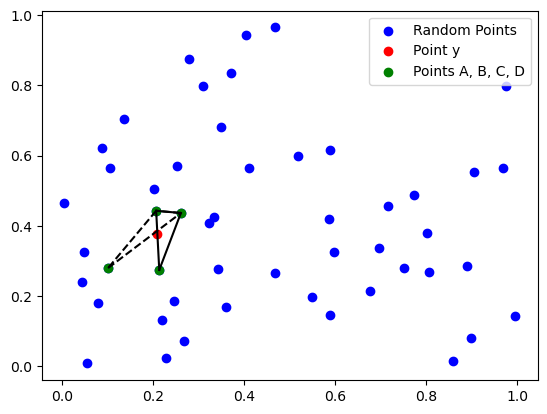

In [720]:
import numpy as np
import matplotlib.pyplot as plt

# Function to compute barycentric coordinates
def barycentric_coordinates(A, B, C, y):
    denominator = (B[1] - C[1]) * (A[0] - C[0]) + (C[0] - B[0]) * (A[1] - C[1])
    
    r1 = ((B[1] - C[1]) * (y[0] - C[0]) + (C[0] - B[0]) * (y[1] - C[1])) / denominator
    r2 = ((C[1] - A[1]) * (y[0] - C[0]) + (A[0] - C[0]) * (y[1] - C[1])) / denominator
    r3 = 1 - r1 - r2
    
    return r1, r2, r3

# Function to define points A, B, C, D
def define_points(X, y):
    A = min(X, key=lambda x: (x[0] - y[0])**2 + (x[1] - y[1])**2 if x[0] > y[0] and x[1] > y[1] else float('inf'))
    B = min(X, key=lambda x: (x[0] - y[0])**2 + (x[1] - y[1])**2 if x[0] > y[0] and x[1] < y[1] else float('inf'))
    C = min(X, key=lambda x: (x[0] - y[0])**2 + (x[1] - y[1])**2 if x[0] < y[0] and x[1] > y[1] else float('inf'))
    D = min(X, key=lambda x: (x[0] - y[0])**2 + (x[1] - y[1])**2 if x[0] < y[0] and x[1] < y[1] else float('inf'))
    
    return A, B, C, D

# Function to check if point is inside triangle
def is_point_in_triangle(A, B, C, y):
    r1, r2, r3 = barycentric_coordinates(A, B, C, y)
    return (0 <= r1 <= 1) and (0 <= r2 <= 1) and (0 <= r3 <= 1)

# Algorithm function
def algorithm(X, y):
    A, B, C, D = define_points(X, y)
    
    if any(np.isinf([A, B, C, D]).flatten()):
        return np.nan
    
    if is_point_in_triangle(A, B, C, y):
        return y
    if is_point_in_triangle(C, D, A, y):
        return y
    if is_point_in_triangle(D, A, B, y):
        return y
    
    return np.nan

# Generate random points
rng = np.random.default_rng(2024)
X = rng.uniform(size=(50, 2))
y = rng.uniform(size=(2,))

A, B, C, D = define_points(X, y)

# Execute the algorithm
result = algorithm(X, y)
result

# Plotting the points and triangles
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Random Points')
plt.scatter(y[0], y[1], color='red', label='Point y')
plt.scatter([A[0], B[0], C[0], D[0]], [A[1], B[1], C[1], D[1]], color='green', label='Points A, B, C, D')

plt.plot([A[0], B[0]], [A[1], B[1]], 'k-')
plt.plot([B[0], C[0]], [B[1], C[1]], 'k-')
plt.plot([C[0], A[0]], [C[1], A[1]], 'k-')

plt.plot([C[0], D[0]], [C[1], D[1]], 'k--')
plt.plot([D[0], A[0]], [D[1], A[1]], 'k--')
plt.plot([A[0], C[0]], [A[1], C[1]], 'k--')

plt.legend()
plt.show()


**Question 2:** Compute the barycentric coordinates of the point $y$ with respect to the triangles $ABC$ and $CDA$. Which triangle is $y$ located inside?

In [721]:
# Compute barycentric coordinates of y with respect to triangle ABC
r1_ABC, r2_ABC, r3_ABC = barycentric_coordinates(A, B, C, y)
# Compute barycentric coordinates of y with respect to triangle CDA
r1_CDA, r2_CDA, r3_CDA = barycentric_coordinates(C, D, A, y)

# Print the barycentric coordinates
print(f"Barycentric coordinates with respect to ABC: r1={r1_ABC}, r2={r2_ABC}, r3={r3_ABC}")
print(f"Barycentric coordinates with respect to CDA: r1={r1_CDA}, r2={r2_CDA}, r3={r3_CDA}")

# Determine which triangle contains the point y
inside_ABC = is_point_in_triangle(A, B, C, y)
inside_CDA = is_point_in_triangle(C, D, A, y)

triangle_containing_y = "ABC" if inside_ABC else "CDA" if inside_CDA else "None"
print(f"Point y is located inside the triangle: {triangle_containing_y}")


Barycentric coordinates with respect to ABC: r1=0.0008797864519075784, r2=0.38563723321707083, r3=0.6134829803310216
Barycentric coordinates with respect to CDA: r1=-0.13392661883334067, r2=0.3682598757102867, r3=0.7656667431230542
Point y is located inside the triangle: ABC


Now consider the function:
$$
f(x_1,x_2) = x_1 \cdot x_2
$$

In [722]:
f = lambda x: x[0]*x[1]
F = np.array([f(x) for x in X])

**Question 3:** Compute the approximation of $f(y)$ using the full algorithm. Compare with the true value.

In [723]:
# Define the function f(x1, x2) = x1 * x2
f = lambda x: x[0] * x[1]

# Compute the true value of f(y)
true_value = f(y)

# Compute the function values at points A, B, and C
f_A = f(A)
f_B = f(B)
f_C = f(C)

# Use barycentric coordinates to approximate f(y)
approx_value = r1_ABC * f_A + r2_ABC * f_B + r3_ABC * f_C

true_value, approx_value


(0.0789565216259594, 0.07868737084487641)

**Question 4:** Repeat question 3 for all points in the set $Y$.

In [724]:
Y = [(0.2,0.2),(0.8,0.2),(0.8,0.8),(0.8,0.2),(0.5,0.5)]

In [725]:
# Function to compute the approximation for a single point y
def compute_approximation(y, A, B, C, D):
    # Compute the true value of f(y)
    true_value = f(y)
    
    # Determine the triangle containing y
    if is_point_in_triangle(A, B, C, y):
        r1, r2, r3 = barycentric_coordinates(A, B, C, y)
        f_A, f_B, f_C = f(A), f(B), f(C)
        approx_value = r1 * f_A + r2 * f_B + r3 * f_C
    elif is_point_in_triangle(C, D, A, y):
        r1, r2, r3 = barycentric_coordinates(C, D, A, y)
        f_C, f_D, f_A = f(C), f(D), f(A)
        approx_value = r1 * f_C + r2 * f_D + r3 * f_A
    else:
        approx_value = np.nan
    
    return true_value, approx_value

# Compute the true and approximate values for all points in Y
results = [compute_approximation(y, A, B, C, D) for y in Y]
results

[(0.04000000000000001, nan),
 (0.16000000000000003, nan),
 (0.6400000000000001, nan),
 (0.16000000000000003, nan),
 (0.25, nan)]